In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import ipywidgets as widgets
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from typing import Mapping, Tuple
from ucimlrepo import fetch_ucirepo
from src.ABC_Multi import ABC_Multi
from benchmarks import multiobjective_fitness
from benchmarks import gsa_svm_fitness

In [3]:
uci_datasets = ["Breast Cancer Wisconsin (Original)",
                "Spambase",
                "Mushroom"]

widget_opt = widgets.Dropdown(
    options=uci_datasets,
    description='Dataset: '
)

display(widget_opt)

Dropdown(description='Dataset: ', options=('Breast Cancer Wisconsin (Original)', 'Spambase', 'Mushroom'), valu…

In [4]:
def fetch_categorical_dataset(_id: int) -> Tuple[pd.DataFrame, pd.Series]:
    data = fetch_ucirepo(id=_id)
    X = data.data.features.copy()
    y = data.data.targets
    encoder = LabelEncoder()
    for col in X.columns:
        X[col] = encoder.fit_transform(X[col])
    return X, y

if widget_opt.value == "Breast Cancer Wisconsin (Original)":
    data = fetch_ucirepo(id=15)
    X = data.data.features
    y = data.data.targets
    X = X.fillna(value=0)
elif widget_opt.value == "Spambase":
    X, y = fetch_categorical_dataset(_id=94)
elif widget_opt.value == "Mushroom":
    X, y = fetch_categorical_dataset(_id=73)

dataset_name = widget_opt.value
    
# Name of selected dataset and summary (number of instances, features, etc.)
print(f"Dataset: {widget_opt.value}")
print(f"Instances: {X.shape[0]} (Train / Test: 80% / 20%)")
print(f"Features: {X.shape[1]}")

Dataset: Breast Cancer Wisconsin (Original)
Instances: 699 (Train / Test: 80% / 20%)
Features: 9


In [5]:
# WARNING!! GLOBAL VARIABLES
wa = 0.8
wf = 0.2

# IMPORTANT!! MUTABLE GLOBAL VARIABLE
conf_matrix_dict = {"TP": 0, "FP": 0, "TN": 0, "FN": 0}
precision = 0.0
recall = 0.0
f1 = 0.0

class UCI:
    """
    Class to handle UCI datasets
    
    Args:
        X (pd.DataFrame): Features
        y (pd.Series): Target
    """
    def __init__(self,
                 X: pd.DataFrame,
                 y: pd.Series,
                 boundaries: Mapping[str, Tuple[Tuple[float, float], ...]],
                 seed: int = 5
                 ) -> None:
        """
        Constructor
        
        Args:
            X (pd.DataFrame): Features
            y (pd.Series): Target
            boundaries (Mapping[str, Tuple[Tuple[float, float], ...]): Boundaries for the optimization problem
            seed (int, optional): Random seed. Defaults to 5.
        """
        self.boundaries = boundaries

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        X_train_full, X_test, y_train_full, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=seed)
        X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=seed)

        self.X_train_full = X_train_full
        self.X_test = X_test
        self.y_train_full = y_train_full
        self.y_test = y_test
        self.X_train_sub = X_train_sub
        self.y_train_sub = y_train_sub
        self.X_val = X_val
        self.y_val = y_val

    def get_fitness(self,
                    solution: Mapping[str, np.ndarray],
                    use_test_data: bool = False,
                    show_confusion_matrix: bool=False
                    ) -> Tuple[float, float, float]:
        """
        Get fitness of a solution
        
        Args:
            solution (Mapping[str, np.ndarray]): Solution to evaluate
            data (Union[None, Tuple[np.ndarray, np.ndarray]], optional): Data to evaluate the solution. Defaults to None.
        
        Returns:
            Tuple[float, float]: Fitness and accuracy of the solution    
        """
        discrete_array = solution["discrete"]     
        gamma, C = solution['real']
        gamma /= 1_000
        C /= 1_000

        global precision, recall, f1
        features_mask = solution["discrete"] == 1
        svc_model = SVC(gamma=gamma, C=C, kernel="rbf", verbose=False)
        if not use_test_data:
            X_train_filtered = self.X_train_sub[:, features_mask]
            X_eval = self.X_val[:, features_mask]

            y_train = self.y_train_sub
            y_eval = self.y_val
        else:
            X_train_filtered = self.X_train_full[:, features_mask]
            X_eval = self.X_test[:, features_mask]

            y_train = self.y_train_full
            y_eval = self.y_test
        
        classes = np.unique(y_eval)
        svc_model.fit(X_train_filtered, np.ravel(y_train))
        y_predict = svc_model.predict(X_eval)
        conf_matrix = confusion_matrix(y_eval, y_predict)
        if show_confusion_matrix:
            # Update global conf_matrix_dict
            conf_matrix_dict["TP"] = conf_matrix[1, 1]
            conf_matrix_dict["FP"] = conf_matrix[0, 1]
            conf_matrix_dict["TN"] = conf_matrix[0, 0]
            conf_matrix_dict["FN"] = conf_matrix[1, 0]
            print(conf_matrix)
        accuracy = accuracy_score(y_eval, y_predict)
        precision = precision_score(y_eval, y_predict, pos_label=classes[1],zero_division=0) * 100
        recall = recall_score(y_eval, y_predict, pos_label=classes[1],zero_division=0) * 100
        f1 = f1_score(y_eval, y_predict, pos_label=classes[1],zero_division=0) * 100
        

        num_features, minimized_acc = multiobjective_fitness(accuracy, discrete_array=discrete_array)
        
        fitness, _ = gsa_svm_fitness(accuracy=accuracy * 100, discrete_array=discrete_array, wa=wa, wf=wf)

        return fitness, num_features, minimized_acc

boundaries = {'real': (1, 100_000), 'discrete': (0, 1)}


In [6]:
def run_abc_mo(X, y, boundaries,
            runs: int=10,
            population_size: int=5,
            generations: int=10) -> Tuple[pd.DataFrame, pd.DataFrame]:
    
    global_train_hist = pd.DataFrame()
    global_test_hist = pd.DataFrame(columns=["run", "accuracy", "precision", "recall", "f1", "fitness", "TP", "FP", "TN", "FN"])
    
    for k in range(runs):
        print(f"Run number {k + 1}")

        uci_data = UCI(X, y, boundaries)
        
        abc_multi = ABC_Multi(objective_function = uci_data.get_fitness,
                       r_dim=2,
                       d_dim=uci_data.X_train_full.shape[1],
                       boundaries=uci_data.boundaries, limit=5)
        
        training_history = abc_multi.optimize_mo(population_size=population_size, generations=generations)
        
        training_history.insert(0, "run", k)
        global_train_hist = pd.concat([global_train_hist, training_history], axis=0)
        
        print(abc_multi.solution_history[-1])
        fitness, _, accuracy = uci_data.get_fitness(solution=abc_multi.solution_history[-1],
                                            use_test_data=True,
                                            show_confusion_matrix=True)
        
        max_acc = (1.0 - accuracy) * 100
        global_test_hist.loc[len(global_test_hist)] = [k, max_acc, precision, recall, f1, fitness, conf_matrix_dict["TP"], conf_matrix_dict["FP"], conf_matrix_dict["TN"], conf_matrix_dict["FN"]]
        
        print(" Test Accuracy: ", max_acc, " - Fitness: ", fitness)
    
    return global_train_hist, global_test_hist

In [ ]:
output_dir = f'../data/output/{dataset_name}'
os.makedirs(output_dir, exist_ok=True)

tr_df, tt_df = run_abc_mo(
    X=X, y=y, boundaries=boundaries,
    runs=100,
    population_size=5,
    generations=10
)

tr_df.to_csv(f'{output_dir}/abc_mo_train_history.csv', index=False)
tt_df.to_csv(f'{output_dir}/abc_mo_test_results.csv', index=False)

import winsound
winsound.Beep(440, 1000) # 440 Hz durante 1000 milisegundos

Run number 1
ABC_MO is optimizing...
The best bee has a fitness of: 91.1904761904762
{'real': array([1.00000000e+00, 7.20556122e+04]), 'discrete': array([0, 0, 1, 0, 0, 0, 0, 0, 1]), 'accuracy': np.float64(0.0267857142857143), 'num_features': np.float64(0.3333333333333333), 'trials': np.int64(4), 'fitness': np.float64(91.1904761904762), 'ranking': np.int64(1), 'niche_count': np.int64(9)}
[[83  8]
 [ 3 46]]
 Test Accuracy:  92.14285714285714  - Fitness:  89.26984126984127
Run number 2
ABC_MO is optimizing...
The best bee has a fitness of: 94.12698412698413
{'real': array([  1286.68586779, 100000.        ]), 'discrete': array([0, 0, 0, 0, 0, 0, 0, 1, 0]), 'accuracy': np.float64(0.017857142857142905), 'num_features': np.float64(0.2222222222222222), 'trials': np.int64(2), 'fitness': np.float64(94.12698412698413), 'ranking': np.int64(1), 'niche_count': np.int64(4)}
[[83  8]
 [ 6 43]]
 Test Accuracy:  90.0  - Fitness:  89.77777777777777
Run number 3
ABC_MO is optimizing...
The best bee has a

KeyboardInterrupt: 

In [8]:
ultimas_generaciones = tr_df.groupby('run').last()

# Exactitud en Train
mean_train_acc = ultimas_generaciones['Accuracy'].mean()
std_train_acc = ultimas_generaciones['Accuracy'].std()

# Métricas en Test
mean_test_acc = tt_df['accuracy'].mean()
std_test_acc = tt_df['accuracy'].std()

mean_test_precision = tt_df['precision'].mean()
std_test_precision = tt_df['precision'].std()

mean_test_recall = tt_df['recall'].mean()
std_test_recall = tt_df['recall'].std()

mean_test_f1 = tt_df['f1'].mean()
std_test_f1 = tt_df['f1'].std()

total_runs = len(tt_df)

print("=" * 50)
print(f"RESULTADOS FINALES DEL ABC Mulitobjetivo ({total_runs} ejecuciones)")
print("=" * 50)
print(f"Exactitud en Train:  {mean_train_acc:.2f}% ± {std_train_acc:.2f}%")
print("-" * 50)
print(f"Exactitud en Test:  {mean_test_acc:.2f}% ± {std_test_acc:.2f}%")
print(f"Precisión en Test:  {mean_test_precision:.2f}% ± {std_test_precision:.2f}%")
print(f"Recall en Test:     {mean_test_recall:.2f}% ± {std_test_recall:.2f}%")
print(f"F1-Score en Test:   {mean_test_f1:.2f}% ± {std_test_f1:.2f}%")
print("-" * 50)

RESULTADOS FINALES DEL ABC Mulitobjetivo (100 ejecuciones)
Exactitud en Train:  95.44% ± 2.22%
--------------------------------------------------
Exactitud en Test:  90.96% ± 2.54%
Precisión en Test:  84.69% ± 5.63%
Recall en Test:     91.51% ± 7.24%
F1-Score en Test:   87.60% ± 3.73%
--------------------------------------------------


In [9]:
import numpy as np

ultimas_generaciones = tr_df.groupby('run').last()

features_por_run = ultimas_generaciones['Discrete'].apply(np.sum)

mean_features = features_por_run.mean()
std_features = features_por_run.std()

mean_features_rounded = round(mean_features)
std_features_rounded = round(std_features)

total_features = len(ultimas_generaciones['Discrete'].iloc[0]) 

print(f"Media de características usadas: {mean_features_rounded} ± {std_features_rounded} (de un total de {total_features} posibles)")

Media de características usadas: 3 ± 1 (de un total de 9 posibles)


In [24]:
ultimas_generaciones = tr_df.groupby('run').last()

# Tiempos por ejecución (en segundos)
mean_time = ultimas_generaciones['ExecutionTime'].mean()
std_time = ultimas_generaciones['ExecutionTime'].std()
total_time = ultimas_generaciones['ExecutionTime'].sum()

print("=" * 50)
print("TIEMPOS DE EJECUCIÓN")
print("=" * 50)
print(f"Tiempo medio por run: {mean_time:.2f} s ± {std_time:.2f} s")
print(f"Tiempo total ({total_runs} runs): {total_time:.2f} s ({total_time / 60:.2f} min)")
print("=" * 50)

TIEMPOS DE EJECUCIÓN
Tiempo medio por run: 27.23 s ± 6.16 s
Tiempo total (10 runs): 272.26 s (4.54 min)


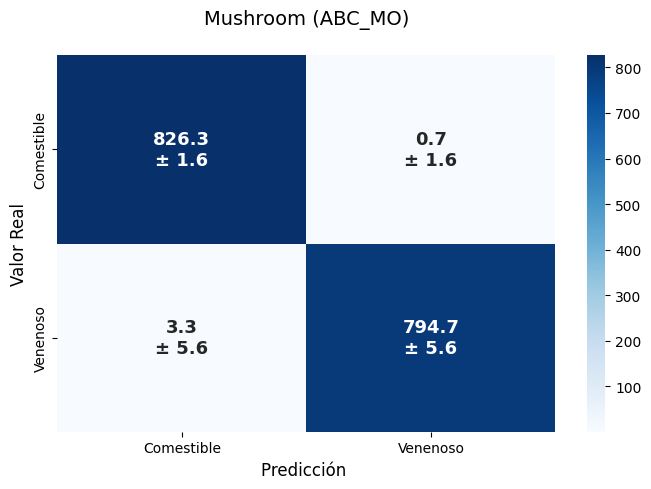

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular media y desviación estándar de cada cuadrante
mean_TP, std_TP = tt_df['TP'].mean(), tt_df['TP'].std()
mean_TN, std_TN = tt_df['TN'].mean(), tt_df['TN'].std()
mean_FP, std_FP = tt_df['FP'].mean(), tt_df['FP'].std()
mean_FN, std_FN = tt_df['FN'].mean(), tt_df['FN'].std()

# 2. Construir la matriz de valores medios (para el color del heatmap)
mean_matrix = np.array([
    [mean_TN, mean_FP],
    [mean_FN, mean_TP]
])

# 3. Construir la matriz de etiquetas de texto (Media ± Desviación)
annotations = np.array([
    [f"{mean_TN:.1f}\n± {std_TN:.1f}", f"{mean_FP:.1f}\n± {std_FP:.1f}"],
    [f"{mean_FN:.1f}\n± {std_FN:.1f}", f"{mean_TP:.1f}\n± {std_TP:.1f}"]
])

# 4. Dibujar la matriz de confusión
plt.figure(figsize=(7, 5))
sns.heatmap(mean_matrix, annot=annotations, fmt='', cmap='Blues', cbar=True,
            xticklabels=['Comestible', 'Venenoso'],
            yticklabels=['Comestible', 'Venenoso'],
            annot_kws={"size": 13, "weight": "bold"})

plt.title('Mushroom (ABC_MO)\n', fontsize=14)
plt.xlabel('Predicción ', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)
plt.tight_layout()
plt.show()

In [35]:
# 1. Calcular la media de exactitud en test y buscar la más cercana
mean_test_acc = tt_df['accuracy'].mean()
distancias = (tt_df['accuracy'] - mean_test_acc).abs()
ejecuciones_mas_cercanas = tt_df[distancias == distancias.min()]
solucion_representativa = ejecuciones_mas_cercanas.sample(n=1)

# 2. Extraer el número de 'run' ganador
run_id = int(solucion_representativa['run'].iloc[0])

# 3. Buscar los parámetros de ese run en la última generación de tr_df
ultima_gen_run = tr_df[tr_df['run'] == run_id].iloc[-1]
valores_reales = ultima_gen_run['Real']
vector_discreto = ultima_gen_run['Discrete']

# 4. Mostrar todos los resultados
print("==================================================")
print(f"Media global de exactitud (Test): {mean_test_acc:.4f}%")
print("==================================================")
print(f"RENDIMIENTO DE LA SOLUCIÓN REPRESENTATIVA (Run {run_id}):")
display(solucion_representativa)

print("\nPARÁMETROS DEL MODELO (Extraídos de tr_df):")
print(f"Valores Reales (C, Gamma): {valores_reales}")
print(f"Vector Discreto (Características seleccionadas):")
print(vector_discreto)

Media global de exactitud (Test): 89.2001%
RENDIMIENTO DE LA SOLUCIÓN REPRESENTATIVA (Run 28):


,run,accuracy,precision,recall,f1,fitness,TP,FP,TN,FN
28,28.0,89.250814,90.491803,79.768786,84.792627,82.628722,276.0,29.0,546.0,70.0



PARÁMETROS DEL MODELO (Extraídos de tr_df):
Valores Reales (C, Gamma): [1.e+00 1.e+05]
Vector Discreto (Características seleccionadas):
[1 0 0 1 0 0 1 1 0 1 0 1 1 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 1 0 1 1 1 0 1 0 0 1 1]
